# Notebook 7: Performance Comparison — NW-flex vs BWA-MEM
This notebook compares NW-flex against BWA-MEM, a widely used short-read aligner, on simulated reads from real human STR loci. Where Notebook 6 demonstrated the alignment workflow on a synthetic single locus with random flanks, here we approach real-world conditions: the loci come from a panel of human STR sites in hg38, carrying their genuine flank sequences and repeat motifs. Reads are tiled across haplotypes that vary from the reference in repeat count and (optionally) a single flank base, and we ask under what conditions each method recovers the haplotype's repeat-region length.

**A note on BWA-MEM.** BWA-MEM is a two-stage aligner. It first performs a *global seed search* of the reference, finding maximal exact matches anywhere in the genome. It then performs *local alignment* by Smith-Waterman extension around the most promising seeds, scored with an affine-gap scheme. Soft-clipping arises in this second stage: when extending past a seed costs more than declaring the read end "clipped", BWA-MEM emits an `S` op in the CIGAR. By raising the soft-clip penalty so high that clipping never improves the score, we can effectively disable soft-clipping — letting us see what BWA-MEM does at the boundary when it can't escape into a clip.

## Overview

In this notebook we:

1. **Build the locus simulation** on a panel of real STR loci drawn from hg38 (selected to be pure and locally-isolated). The four stages — reference, haplotype, reads, and mirror — produce reads from an allelic variant of a genomic region that contains a tandem repeat. The last stage generates a "mirror" simulation where all the elements are reverse-complemented.

2. **Use a BWA-MEM-compatible scoring scheme.** NW-flex's defaults module ships with several alternative scoring schemes; for this notebook we select the one whose match, mismatch, gap-open, and gap-extend values match BWA-MEM's defaults, so the two methods see the same scoring landscape on every read.

3. **Set up three alignment configurations**: BWA-MEM at standard parameters; BWA-MEM with the soft-clip penalty raised so high that clipping never improves the score; and NW-flex with the STR-aware EP pattern from Notebook 4. Each configuration runs on both the forward and mirror frames produced by the simulation.

4. **Run two comparisons**, each changing one thing about the simulation:
   - **Length variation only** — haplotype repeat count varies, flanks unchanged.
   - **One SNV in the flank** — same sweep with a single base change two bp into the left flank from the repeat boundary.
   - A third comparison with two adjacent STRs is presented in the next notebook.

5. **Tabulate correctness** for each method as a function of read flank extent and the haplotype's $\Delta$. The verdict combines a length check (does the alignment recover the haplotype's repeat-region length?) with a score check (is the chosen alignment's score equal, lower, or higher than the expected alignment's score?). 

The methods differ structurally: when the only difference between haplotype and reference is the repeat count, NW-flex's EP pattern is guaranteed to find the optimum, while a clip-based aligner depends on the scoring tradeoffs it makes at the boundary. Flank variations expose all aligners to score optimizations that may alter the measured repeat length.

This notebook builds on:

- **Notebook 4**: STR specialization and the phase-preserving EP pattern.
- **Notebook 6**: STR locus simulation and pileup.

**IMPORTANT:** The notebook runs on the included hg38 panel TSV plus `bwa` and `samtools` on `PATH`. If those are missing, the BWA cells skip cleanly with an installation hint.


## Imports and setup



### Imports

Standard scientific-Python imports plus the core NW-flex pieces this notebook builds on. Notebook-specific helpers (panel loading, BWA wrapper, CIGAR decoder) will be added here as the cells that need them are written.

In [1]:
# 🧙 Notebook magic: autoreload modules
%load_ext autoreload
%autoreload 2

# Standard library
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Scientific Python
import pandas as pd

# Notebook display
from IPython.display import display

# NW-flex core
from nwflex.default import get_default_scoring
from nwflex.ep_patterns import build_EP_STR_phase
from nwflex.repeats import STRLocus

# NW-flex simulation
from nwflex.simulation import (
    align_bwa,
    align_nwflex,
    alignment_state,
    state_to_glyph,
    build_haplotype,
    build_locus_from_panel,
    build_mirror_frame,
    BWAMethod,
    NWFlexMethod,
    bwa_truth_cigar,
    make_variant,
    nwflex_truth_cigar,
    pivot_for_heatmap,
    sweep,
    plot_correctness_heatmap,
    plot_correctness_heatmap_rows,
    plot_layout_schematic,
    rc_cigar_to_forward,
    score_alignment,
    tile_reads,
)

### BWA-MEM and samtools availability

The BWA arms of this notebook shell out to `bwa` and `samtools`, which must be on `PATH`. The cell below checks both; if either is missing, the BWA cells skip cleanly with an installation hint.

In [2]:
required = ("bwa", "samtools")
missing = [t for t in required if shutil.which(t) is None]
if missing:
    print(f"Missing on PATH: {', '.join(missing)}")
    print(f"Install with: conda install -c bioconda {' '.join(missing)}")
    print("BWA-MEM cells will be skipped if these are unavailable.")
else:
    print(f"Found on PATH: {', '.join(required)}")

Found on PATH: bwa, samtools


### Scoring scheme

NW-flex ships several alternative scoring schemes in `nwflex.default`, each a `(score_matrix, gap_open, gap_extend, alphabet_to_undex)` tuple keyed by name. The original NW-flex defaults were chosen for legibility in the teaching notebooks; the additional schemes target compatibility with external aligners.

For this notebook we select the **BWA-MEM-compatible** scheme so that NW-flex and BWA-MEM see matches, mismatches, and gaps under identical costs. With matched scoring, any disagreement between the two methods reflects what each algorithm prefers given the same alignment landscape.

### Same scoring scheme, different alignment scores

While we selected matching alignment parameters, the BWA-MEM results return Smith-Waterman scores that are not strictly comparable to the NW-flex scores.

- **SW score** is BWA-MEM's reported `AS:i:` tag — the Smith-Waterman / local-extension score. BWA-MEM extends from a seed and reports the maximum cumulative score it sees *during* extension, which can sit at an interior cell when the optimal global path dips through an indel.

- **NW score** is the Needleman-Wunsch / global score recomputed from the achieved CIGAR by `score_alignment`, using the same match/mismatch/gap parameters. Soft-clips are charged the same affine-gap penalty as a deletion of the same length: leading or terminal read bases that don't align should not score better than read bases that align poorly.

Throughout the rest of this notebook we use the **NW score** whenever we *evaluate* an alignment. It is well-defined for any CIGAR (BWA's output, NW-flex's output, or a constructed ground-truth alignment), and it matches NW-flex's reported `RefAligner` score by construction on CIGARs without soft-clip ops.

In [3]:
# BWA-MEM-compatible scoring (+1 / -4 / -6 / -1).
score_matrix, gap_open, gap_extend, a2i = get_default_scoring("bwa_mem")

# Packed scoring kwargs — reused by every downstream call that needs to
# rescore an alignment or run NW-flex / score-aware classify.
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

### Input panel


The simulation draws each locus from a panel of human STR sites stored at `data/hg38_motif_sample_K100.tsv`. The panel was built using [Tandem Repeat Finder (TRF)](https://tandem.bu.edu/trf/trf.html) run on hg38 and the results filtered to keep only loci that are *pure* (a clean run of a single canonical motif) and *locally isolated* (no other repeats in the surrounding flank window). Each row gives a genomic location, the motif and tract as found in the reference, and the flanking sequences we use to build the simulation reference. The panel has example loci for mono, di and trinucleotide motifs.

Schema:
| Column | Meaning |
|---|---|
| `pind` | panel index (locus identifier) |
| `chr`, `start_38`, `stop_38`, `strand` | hg38 coordinates of the repeat tract |
| `type` | canonical motif (e.g. `A`, `AC`, `AGG`) |
| `lflank`, `rflank` | left and right flank sequences (500bp) |
| `ms_seq` | repeat tract as it appears in hg38 |
| `ref_score_per_base` | per-base purity score (1.0 = perfect tract) |


> The panel construction (TRF run, the purity / isolation filters, and the panel-construction steps) is documented in [`Appendix_TRF.ipynb`](Appendix_TRF.ipynb).

In [4]:
PANEL_PATH = Path("../data/hg38_motif_sample_K100.tsv")
panel = pd.read_csv(PANEL_PATH, sep="\t")

display(panel.head())

print(f"{len(panel):,} loci total")
print()
print("Motif-length breakdown:")
for k, v in panel["type"].str.len().value_counts().sort_index().items():
    print(f"  {k}-bp motif:  {v:>3} loci")

,pind,chr,start_38,stop_38,strand,type,lflank,rflank,ms_seq,ref_score_per_base
0,0,chr1,36351,36364,+,A,CCATCTCTGGGCCCAGAATGACCCACTGGAGACCTTACAGCTCTCC...,CCCAGCCTGGCGGAAAGAATTTAAATTATAAAAACTTAGAAGTATG...,AAAAAAAAAAAAA,1.0
1,1,chr1,51864,51877,+,A,GTGGGGGTTGAGTTTCACTTTATTTAAAGTGAGTCTTAATCCTCCA...,GAAGATTGATCAGAGAGTACCTCCCCTAAGGGTACATGCAGATAAA...,AAAAAAAAAAAAA,1.0
2,2,chr1,71175,71186,+,A,AGTATATTACTTGGATCCATCTATGTCATTTTCCATGGTTAATGTT...,CCTTAACAAATGATTCTGACAAATATCTTCTCTTTCCAGGGAGAAT...,AAAAAAAAAAA,1.0
3,3,chr1,77174,77195,+,A,CTTCATGTCTAAAACACCGAGAGAGGCACTCTTATGCATTGTTGGT...,GGAAAATAACCAAATGACAATTAGTGAGTACTACTTGCAAAACTTG...,AAAAAAAAAAAAAAAAAAAAA,1.0
4,4,chr1,108545,108561,+,A,TGTACCATGCTCCTCCTTAATCATTCTGAGGTTACATCTTAAGTCC...,GAATGGAGAGAATGCTACATGAGAGAAAGGATCTTATCTATCATGT...,AAAAAAAAAAAAAAAA,1.0


6,900 loci total

Motif-length breakdown:
  1-bp motif:  400 loci
  2-bp motif:  1080 loci
  3-bp motif:  5420 loci


## Locus Simulation

We build the locus simulation in four stages:

1. **Reference** — a sequence with known repeat length and boundary, drawn from the panel. We also build an extended copy with three times the motif copies for NW-flex's EP-skip enumeration to consume.
2. **Haplotype** — a sequence sharing the reference's flanks and motif, with a chosen repeat count and an optional flank SNV.
3. **Reads** — fixed-length segments of the haplotype, each spanning the repeat with some flank on each side.
4. **Mirror** — a reverse-complemented copy of everything above so each aligner can be evaluated on both orientations.


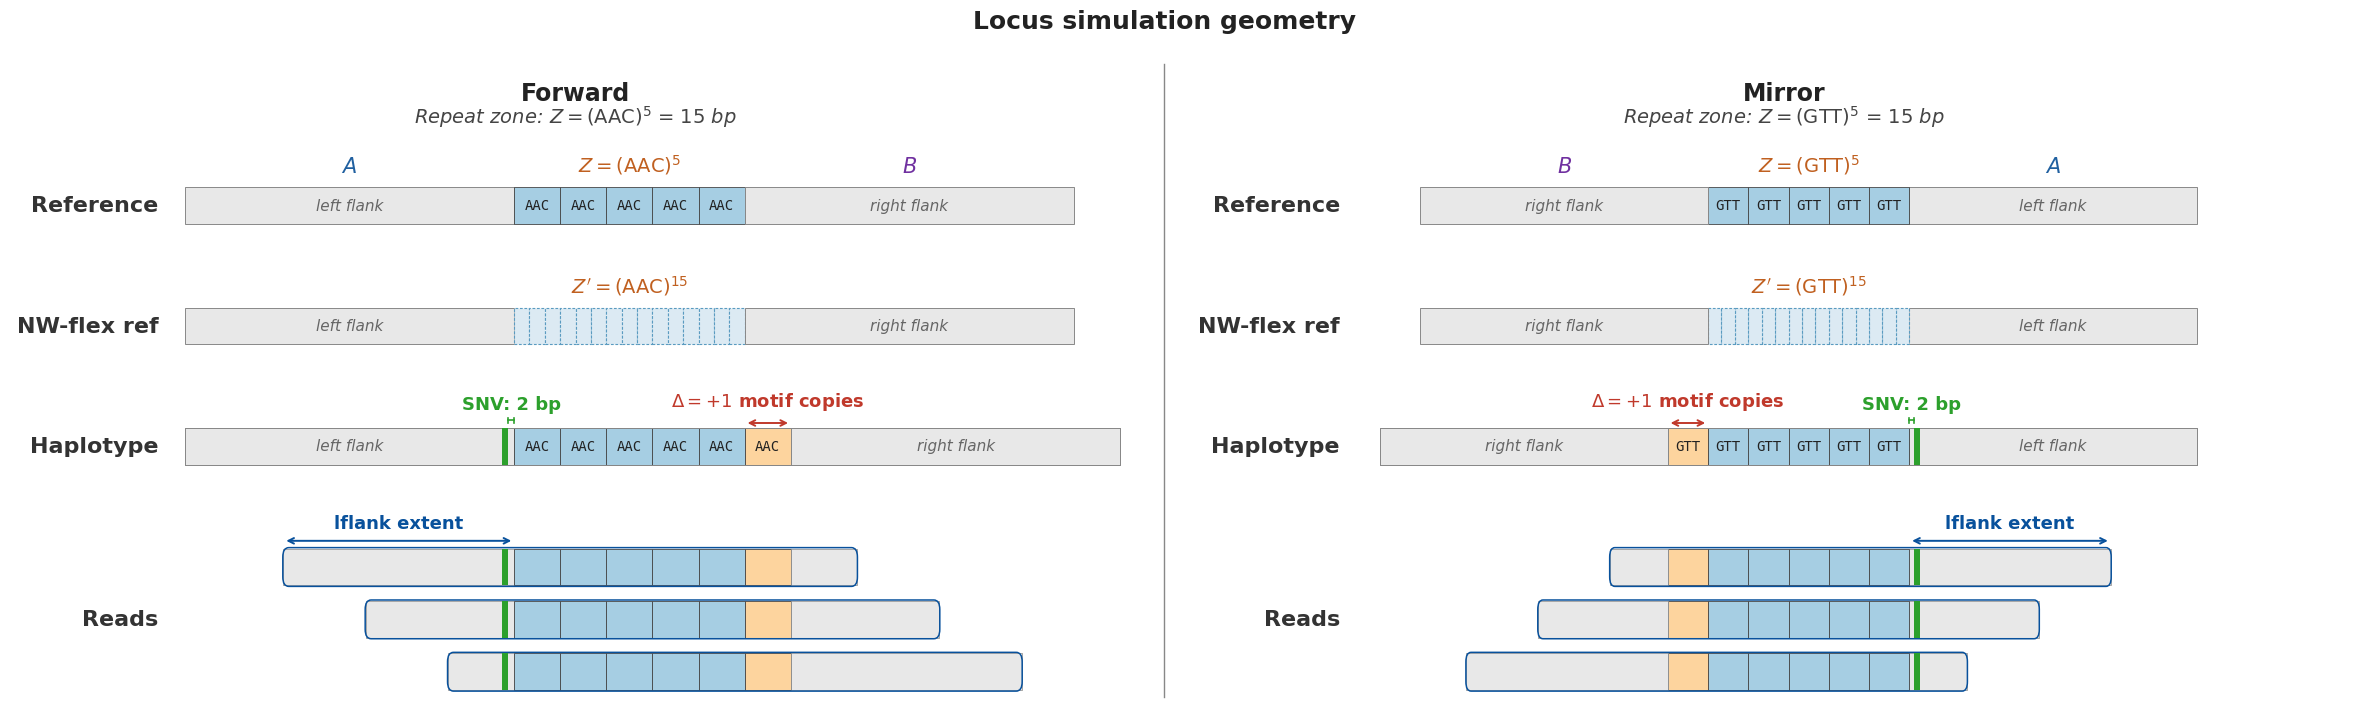

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7.2))
for ax, mirror in zip(axes, [False, True]):
    plot_layout_schematic(
        motif="AAC",
        ref_n=5,
        delta_example=1,
        snv={"offset_from_boundary": 2},
        suptitle="Forward" if not mirror else "Mirror",
        flanks_aligned=False,
        show_nwflex=True,
        mirror=mirror,
        ax=ax,
    )
fig.suptitle("Locus simulation geometry",
             fontsize=18, fontweight="bold", color="#222222", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97), w_pad=2)
# Vertical divider between the two panels at the figure midline.
divider = Line2D([0.5, 0.5], [0.04, 0.92], transform=fig.transFigure,
                 color="#888888", linewidth=1.0, linestyle="-")
fig.add_artist(divider)

### Reference

The reference comes from the panel: a real flank pair, a real repeat motif, and a chosen reference repeat count $N$. Together these give the reference sequence $X = A \cdot R^N \cdot B$. Tandem Repeat Finder chooses the motif rotation so the repeat tract begins on a full motif copy, but it does not require the tract to end on one — any trailing partial copy then sits at the start of the right flank, where it would read as an extension of the repeat. For this reason, we use the function `clean_flank_window` to trim the genomic flanks to a clean motif-edge boundary so the flank/repeat boundary is unambiguous. We trim both flanks just in case.

For NW-flex, we also build an **extended reference** with the same flanks and **three times the motif copies**: $X' = A \cdot R^{3N} \cdot B$. The STR-aware EP pattern (Notebook 4) lets NW-flex contract that long repeat run to any allowed haplotype count in a single pass; picking $3N$ keeps the haplotype sweep ($N + \Delta$ for small $|\Delta|$) well inside the allowed range. We re-use the `STRLocus` dataclass with `N = 3*N` to construct it — same flanks, same motif, just more copies.


In [6]:
LOCUS_FLANK_LEN = 200
NWFLEX_FACTOR   = 3   # NW-flex extended reference uses 3N motif copies

# Pick a representative trinucleotide locus from the panel.
row = panel[panel["type"].str.len() == 3].iloc[0]
ref_n = len(row["ms_seq"]) // len(row["type"])

locus = build_locus_from_panel(
    motif=row["type"],
    panel_lflank=row["lflank"],
    panel_rflank=row["rflank"],
    ref_n=ref_n,
    flank_len=LOCUS_FLANK_LEN,
)

# Extended NW-flex reference: same flanks, same motif, NWFLEX_FACTOR * N copies.
nwflex_locus = STRLocus(
    A=locus.A, R=locus.R, N=NWFLEX_FACTOR * locus.N, B=locus.B,
)

print(f"pind={row['pind']}  motif={locus.R!r}  ref N={locus.N}")
print()
print("Locus reference (X = A · R^N · B):")
print(f"  X length: {locus.n}  ({len(locus.A)} flank + {locus.k * locus.N} repeat + {len(locus.B)} flank)")
print(f"  flank lengths: panel {len(row['lflank'])}/{len(row['rflank'])} bp → locus {len(locus.A)}/{len(locus.B)} bp")
print(f"  z_start={locus.s}  z_end={locus.e}")
print(f"  A[-10:] = {locus.A[-10:]}   (last base must not be {locus.R[-1]!r})")
print(f"  B[:10]  = {locus.B[:10]}   (first base must not be {locus.R[0]!r})")
print()
print(f"NW-flex extended reference (X' = A · R^{NWFLEX_FACTOR}N · B,  N' = {nwflex_locus.N}):")
print(f"  X' length: {nwflex_locus.n}  ({len(nwflex_locus.A)} flank + {nwflex_locus.k * nwflex_locus.N} repeat + {len(nwflex_locus.B)} flank)")
print(f"  z_start={nwflex_locus.s}  z_end={nwflex_locus.e}")


pind=1480  motif='AAC'  ref N=5

Locus reference (X = A · R^N · B):
  X length: 415  (200 flank + 15 repeat + 200 flank)
  flank lengths: panel 500/500 bp → locus 200/200 bp
  z_start=200  z_end=215
  A[-10:] = GCTGCTTATA   (last base must not be 'C')
  B[:10]  = CATTGACAGG   (first base must not be 'A')

NW-flex extended reference (X' = A · R^3N · B,  N' = 15):
  X' length: 445  (200 flank + 45 repeat + 200 flank)
  z_start=200  z_end=245


### Haplotype

The haplotype is the sequence we sample reads from. It shares the reference's flanks and motif but can differ from the reference in two ways: an optional difference in the number of repeat copies, and an optional single-nucleotide variant (SNV) at a chosen position in one of the flanks.

In [7]:
DELTA = 1  # haplotype has one extra repeat copy vs the locus

hap = build_haplotype(locus, delta=DELTA)
rflank_len = len(hap.sequence) - hap.flank_len - hap.body_len

print("An example haplotype:")
print(f"locus N={locus.N}  →  haplotype N={locus.N + DELTA}")
print(f"  hap length: {len(hap.sequence)}  ({hap.flank_len} flank + {hap.body_len} repeat + {rflank_len} flank)")

An example haplotype:
locus N=5  →  haplotype N=6
  hap length: 418  (200 flank + 18 repeat + 200 flank)


### Reads

Each read is a fixed-length contiguous segment of the haplotype. We generate one read at every starting position whose segment covers at least $K$ bases of each flank: this guarantees the read spans the repeat and gives the alignment flank context on both sides. The number of flank bases a read covers on each side is its *flank extent*.

In [8]:
READ_LEN = 150
K_MIN_FLANK = 1

reads = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
lflank_extents = sorted({r.lflank_extent for r in reads})
rflank_extents = sorted({r.rflank_extent for r in reads})

print(f"Tiled {len(reads)} reads (read_len={READ_LEN}, k_min_flank={K_MIN_FLANK})")
print(f"  lflank_extent: {lflank_extents[0]}..{lflank_extents[-1]}")
print(f"  rflank_extent: {rflank_extents[0]}..{rflank_extents[-1]}")

Tiled 131 reads (read_len=150, k_min_flank=1)
  lflank_extent: 1..131
  rflank_extent: 1..131


### Mirror

For symmetric scoring (matches, mismatches, and gaps cost the same in either direction), we would expect aligning a read against a reference to give an equivalent answer to aligning the reverse-complement of the read against the reverse-complement of the reference. In practice this symmetry doesn't always hold — for two reasons:

- **Tie-breaking.** When several alignments share the optimal score, the one returned is determined by the implementation's tie-break rule, which typically depends on the order in which DP cells are scanned. Reversing both read and reference reverses that scan order, so the rc arm can return a different element of the same co-optimum set.
- **Directional heuristics.** BWA-MEM's two-stage pipeline (seed search → Smith-Waterman extension) is direction-dependent: the seeds it finds, and the boundary at which extension gives up and turns into soft-clip, can differ between a read and its reverse complement.

The mirror frame is built into the simulation by design, so the comparison is fair to every aligner. Each one sees both the forward frame `(reference, reads, repeat-zone)` and the mirror frame `(rc-reference, rc-reads, mirrored-zone)`, and the analysis combines both.

The cell below mirrors both the locus reference and the NW-flex extended reference in a single call, so every aligner has its `(reads, reference, zone)` pair on both strands ready before any alignment runs.


In [9]:
(rc_locus_X, rc_reads, rc_zone,
 rc_nwflex_X,           rc_nwflex_zone) = build_mirror_frame(
    reference=locus.X,
    reads=reads,
    zone=(locus.s, locus.e),
    extra_reference=nwflex_locus.X,
    extra_zone=(nwflex_locus.s, nwflex_locus.e),
)

print(f"forward locus  zone = ({locus.s}, {locus.e})")
print(f"mirror  locus  zone = {rc_zone}")
print(f"forward 3N     zone = ({nwflex_locus.s}, {nwflex_locus.e})")
print(f"mirror  3N     zone = {rc_nwflex_zone}")
print()
print(f"forward read[0] lflank/rflank extent = "
      f"{reads[0].lflank_extent}/{reads[0].rflank_extent}")
print(f"mirror  read[0] lflank/rflank extent = "
      f"{rc_reads[0].lflank_extent}/{rc_reads[0].rflank_extent}")


forward locus  zone = (200, 215)
mirror  locus  zone = (200, 215)
forward 3N     zone = (200, 245)
mirror  3N     zone = (200, 245)

forward read[0] lflank/rflank extent = 131/1
mirror  read[0] lflank/rflank extent = 1/131


## Three alignment configurations

We run three alignment configurations per read. Each configuration produces **two alignments**: one for the forward (read, reference) pair from the simulation and one for the mirror (rc-read, rc-reference) pair. Each read therefore yields six alignments across the three configurations:

1. BWA-MEM at standard parameters — forward, mirror.
2. BWA-MEM with soft-clipping suppressed — forward, mirror.
3. NW-flex — forward, mirror.

The aligner harnesses are orientation-agnostic: each takes a list of reads and a reference and aligns each read against that reference. The forward/mirror distinction lives in the simulation, not in the harness call.

### BWA-MEM configurations

BWA-MEM's pipeline is two stages: a global seed search, then Smith-Waterman extension from each viable seed. We index the locus reference (and the mirror reference) once and run `bwa mem` on the corresponding read list.

The two BWA configurations differ only in the soft-clip penalty. **Standard** uses BWA-MEM's defaults, which allow soft-clipping when it improves the local-extension score. **No-clip** raises the soft-clip penalty (`-L 500`) so high that clipping never improves the score, effectively disabling it. This isolates the soft-clip mechanism: a regime where both BWA arms fail is a structural failure, not a clipping artifact.


In [10]:
# Three reads spanning the boundary range.
illustrative_idx = [0, len(reads) // 2, len(reads) - 1]
illustrative_reads        = [reads[i]    for i in illustrative_idx]
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

# Each BWA configuration produces a (forward, mirror) pair of alignments:
# forward reads aligned to the locus reference, mirror reads aligned to
# the mirror reference.  The harness has no orientation knob — the two
# runs differ only in which reads + reference are passed in.
res_std    = align_bwa(locus.X,    illustrative_reads,        no_clip=False)
res_std_rc = align_bwa(rc_locus_X, illustrative_mirror_reads, no_clip=False)
res_noclip = align_bwa(locus.X,    illustrative_reads,        no_clip=True)
res_nc_rc  = align_bwa(rc_locus_X, illustrative_mirror_reads, no_clip=True)

# BWA-MEM reports the SW (Smith-Waterman / local-extension) score in
# its AS:i: tag.  We rescore each achieved CIGAR using `score_alignment`
# to obtain its NW (Needleman-Wunsch / global) score under the same
# affine-gap parameters with soft-clips charged the same penalty as a
# deletion of the same length.
def _nw(read, ref, hit):
    return int(score_alignment(read.sequence, ref, hit.pos, hit.cigar, **sc_kw))

# Mirror CIGARs walk the rc-reference left-to-right; for side-by-side
# comparison we display them in forward-locus coordinates, via
# `rc_cigar_to_forward`.
ref_length = len(locus.X)

# Long-format table: one row per (read, mode, orientation).
table_rows = []
for k, ix in enumerate(illustrative_idx):
    r_fwd = illustrative_reads[k]
    r_rc  = illustrative_mirror_reads[k]
    for mode, h_fwd, h_rc in (
        ("std",     res_std[k],    res_std_rc[k]),
        ("no-clip", res_noclip[k], res_nc_rc[k]),
    ):
        table_rows.append({
            "read": ix,
            "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
            "mode": mode, "orient": "fwd",
            "cigar": h_fwd.cigar,
            "SW score": int(h_fwd.score),
            "NW score": _nw(r_fwd, locus.X, h_fwd),
        })
        table_rows.append({
            "read": ix,
            "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
            "mode": mode, "orient": "mirror",
            "cigar": rc_cigar_to_forward(h_rc.pos, h_rc.cigar, ref_length),
            "SW score": int(h_rc.score),
            "NW score": _nw(r_rc, rc_locus_X, h_rc),
        })

print("BWA-MEM on three illustrative reads "
      "— std vs no-clip, forward vs mirror "
      "(mirror CIGARs shown in forward-locus coordinates):")
pd.DataFrame(table_rows)

BWA-MEM on three illustrative reads — std vs no-clip, forward vs mirror (mirror CIGARs shown in forward-locus coordinates):


,read,lflank,rflank,mode,orient,cigar,SW score,NW score
0,0,131,1,std,fwd,146M4S,146,136
1,0,131,1,std,mirror,146M4S,146,136
2,0,131,1,no-clip,fwd,131M3I16M,146,138
3,0,131,1,no-clip,mirror,146M3I1M,146,138
4,65,66,66,std,fwd,66M3I81M,138,138
5,65,66,66,std,mirror,81M3I66M,138,138
6,65,66,66,no-clip,fwd,66M3I81M,138,138
7,65,66,66,no-clip,mirror,81M3I66M,138,138
8,130,1,131,std,fwd,4S146M,146,136
9,130,1,131,std,mirror,4S146M,146,136


For the centered read (idx 65) SW and NW agree. The boundary reads (idx 0 and 130) diverge for two independent reasons:

- **No-clip** emits the indel-bearing alignment (`131M3I16M` / `1M3I146M`); BWA's reported SW reflects the higher pre-indel maximum, so **SW = 146 while NW = 138**.
- **Standard** soft-clips the boundary instead (`146M4S` / `4S146M`); under NW the soft-clip adds another affine-gap charge of `gap_open + 4·gap_extend = -10`, so **SW = 146 while NW = 136**.

Both gaps go away when we *evaluate* alignments by NW score (which is what the rest of the notebook does).

### NW-flex configuration

The third configuration uses NW-flex for an STR locus, with the extra-spacious $3N$-copy extended reference to give the EP pattern room to contract to the haplotype's repeat count.

The harness `align_nwflex` mirrors `align_bwa`: it takes a reference, a list of reads, and the scoring scheme, and returns one alignment per read in input order. As with BWA, the harness has no orientation knob — we run it twice, once on the forward (read, reference) pair and once on the mirror pair, both built by the simulation setup above.


In [11]:
# EP patterns for the forward and mirror NW-flex references.  Each is
# tied to its reference's repeat-zone coordinates, so the forward and
# mirror frames need their own EP construction.  We define them here
# so downstream sweep cells can reuse them.
ep_fwd = build_EP_STR_phase(
    nwflex_locus.n, nwflex_locus.s, nwflex_locus.e, nwflex_locus.k,
)
ep_rc  = build_EP_STR_phase(
    nwflex_locus.n, *rc_nwflex_zone, nwflex_locus.k,
)

# Mirror reads for the three illustrative indices (paired with the
# forward reads by list index, since build_mirror_frame preserves order
# and var_start).
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

res_nwflex    = align_nwflex(nwflex_locus.X, illustrative_reads,
                              extra_predecessors=ep_fwd, **sc_kw)
res_nwflex_rc = align_nwflex(rc_nwflex_X,    illustrative_mirror_reads,
                              extra_predecessors=ep_rc,  **sc_kw)

# Mirror CIGARs are displayed in forward-locus coordinates.
nwflex_ref_length = len(nwflex_locus.X)

# Long-format table: one row per (read, orientation).  NW-flex has a
# single mode, so the comparison axis here is forward vs mirror only.
table_rows = []
for k, ix in enumerate(illustrative_idx):
    r_fwd = illustrative_reads[k]
    fwd_hit = res_nwflex[k]
    rc_hit  = res_nwflex_rc[k]
    table_rows.append({
        "read": ix,
        "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
        "orient": "fwd",
        "cigar": fwd_hit.cigar,
        "NW score": int(fwd_hit.score),
    })
    table_rows.append({
        "read": ix,
        "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
        "orient": "mirror",
        "cigar": rc_cigar_to_forward(rc_hit.pos, rc_hit.cigar,
                                     nwflex_ref_length),
        "NW score": int(rc_hit.score),
    })

print("NW-flex on three illustrative reads "
      "(3N reference, STR-aware EP; "
      "mirror CIGARs shown in forward-locus coordinates):")
pd.DataFrame(table_rows)

NW-flex on three illustrative reads (3N reference, STR-aware EP; mirror CIGARs shown in forward-locus coordinates):


,read,lflank,rflank,orient,cigar,NW score
0,0,131,1,fwd,131M27N19M,150
1,0,131,1,mirror,149M27N1M,150
2,65,66,66,fwd,66M27N84M,150
3,65,66,66,mirror,84M27N66M,150
4,130,1,131,fwd,1M27N149M,150
5,130,1,131,mirror,19M27N131M,150


### Correctness rule

The table below classifies each (read, configuration) along two axes:

**Length (✓ / ✗).** Did the alignment recover the haplotype's repeat-region length? The check fails when either the alignment doesn't span the repeat (typically a soft-clip eating one of the flanks) or it spans the repeat but decodes the wrong number of motif copies inside. Both conditions must hold for ✓.

**Score vs ground truth (`<` / `=` / `>`).** Compare the chosen alignment's score to the score of the *ground-truth* alignment under the same scoring scheme. A length-correct alignment necessarily matches the ground truth — the ground truth *is* the correct alignment — so this column only carries information when length has failed:

- `<` — heuristic miss: the aligner left score on the table.
- `=` — ground truth was co-optimal; tie-break landed on a different element of the optimum set.
- `>` — the score landscape itself prefers a wrong alignment.


In [12]:
# Per-(read, configuration, orient) verdict glyphs:
#   length: ✓ if the alignment recovers the haplotype's repeat length, ✗ otherwise.
#   score:  <, =, > comparing the chosen NW score to the ground-truth NW score.
# Glyphs come from alignment_state + state_to_glyph in the simulation
# package; this cell just composes them across methods and orientations.
truth_z_bp = hap.body_len

def classify(read, ref, zone, hit, truth_nw, *, convention):
    nw = score_alignment(read.sequence, ref, hit.pos, hit.cigar, **sc_kw)
    state = alignment_state(
        hit.cigar, hit.pos, nw, truth_nw, *zone, truth_z_bp,
        convention=convention,
    )
    return state_to_glyph(state)

# Per-read ground-truth NW scores under each convention (orientation-invariant
# under symmetric scoring).
truth_bwa = [score_alignment(r.sequence, locus.X,
                             *bwa_truth_cigar(r, hap, locus), **sc_kw)
             for r in illustrative_reads]
truth_nwf = [score_alignment(r.sequence, nwflex_locus.X,
                             *nwflex_truth_cigar(r, hap, nwflex_locus), **sc_kw)
             for r in illustrative_reads]

read_labels = [f"r{ix:03d} (lf={r.lflank_extent}, rf={r.rflank_extent})"
               for ix, r in zip(illustrative_idx, illustrative_reads)]

# One lane per (method, orient) carrying everything classify() needs.
# Order matters: it becomes the row order in the final table.
lanes = [
    dict(method="BWA-std",     orient="fwd",    reads=illustrative_reads,        ref=locus.X,        zone=(locus.s, locus.e),                hits=res_std,       convention="bwa",    truth=truth_bwa),
    dict(method="BWA-std",     orient="mirror", reads=illustrative_mirror_reads, ref=rc_locus_X,     zone=rc_zone,                           hits=res_std_rc,    convention="bwa",    truth=truth_bwa),
    dict(method="BWA-no-clip", orient="fwd",    reads=illustrative_reads,        ref=locus.X,        zone=(locus.s, locus.e),                hits=res_noclip,    convention="bwa",    truth=truth_bwa),
    dict(method="BWA-no-clip", orient="mirror", reads=illustrative_mirror_reads, ref=rc_locus_X,     zone=rc_zone,                           hits=res_nc_rc,     convention="bwa",    truth=truth_bwa),
    dict(method="NW-flex", orient="fwd",    reads=illustrative_reads,        ref=nwflex_locus.X, zone=(nwflex_locus.s, nwflex_locus.e),  hits=res_nwflex,    convention="nwflex", truth=truth_nwf),
    dict(method="NW-flex", orient="mirror", reads=illustrative_mirror_reads, ref=rc_nwflex_X,    zone=rc_nwflex_zone,                    hits=res_nwflex_rc, convention="nwflex", truth=truth_nwf),
]

# Build tidy (long-format) records, then pivot to wide.
records = [
    {"method": lane["method"], "orient": lane["orient"],
     "read": read_labels[k],
     "verdict": classify(lane["reads"][k], lane["ref"], lane["zone"],
                         lane["hits"][k], lane["truth"][k],
                         convention=lane["convention"])}
    for lane in lanes
    for k in range(len(illustrative_idx))
]

row_index = pd.MultiIndex.from_tuples(
    [(lane["method"], lane["orient"]) for lane in lanes],
    names=["method", "orient"],
)
verdict_df = (
    pd.DataFrame(records)
      .pivot(index=["method", "orient"], columns="read", values="verdict")
      .reindex(index=row_index, columns=read_labels)
)

print(f"Ground-truth z_bp = (N + Δ) · |R| = {truth_z_bp}    "
      "(length ✓/✗  +  score <, =, > vs ground truth)")
verdict_df

Ground-truth z_bp = (N + Δ) · |R| = 18    (length ✓/✗  +  score <, =, > vs ground truth)


read               r000 (lf=131, rf=1) r065 (lf=66, rf=66) r130 (lf=1, rf=131)
method      orient                                                            
BWA-std     fwd                   ✗  <                ✓  =                ✗  <
            mirror                ✗  <                ✓  =                ✗  <
BWA-no-clip fwd                   ✓  =                ✓  =                ✓  =
            mirror                ✓  =                ✓  =                ✓  =
NW-flex     fwd                   ✓  =                ✓  =                ✓  =
            mirror                ✓  =                ✓  =                ✓  =

## Sweep framework

Both comparisons run through the same sweep over the cartesian product of four dimensions:

- **variant** — haplotype configuration (`delta`; the second comparison adds an `snv_offset` in the left flank)
- **read** — one per `lflank_extent`, in order from `tile_reads`
- **method** — `BWA-std` / `BWA-no-clip` / `NW-flex`
- **orient** — `fwd` / `rc`

The reference per `(method, orient)` is fixed across variants, so every variant's reads can be aligned together in a single batched call per `(method, orient)` and then split apart for per-cell ground truth and classify. The schematic below names the three geometric ranges that get swept.


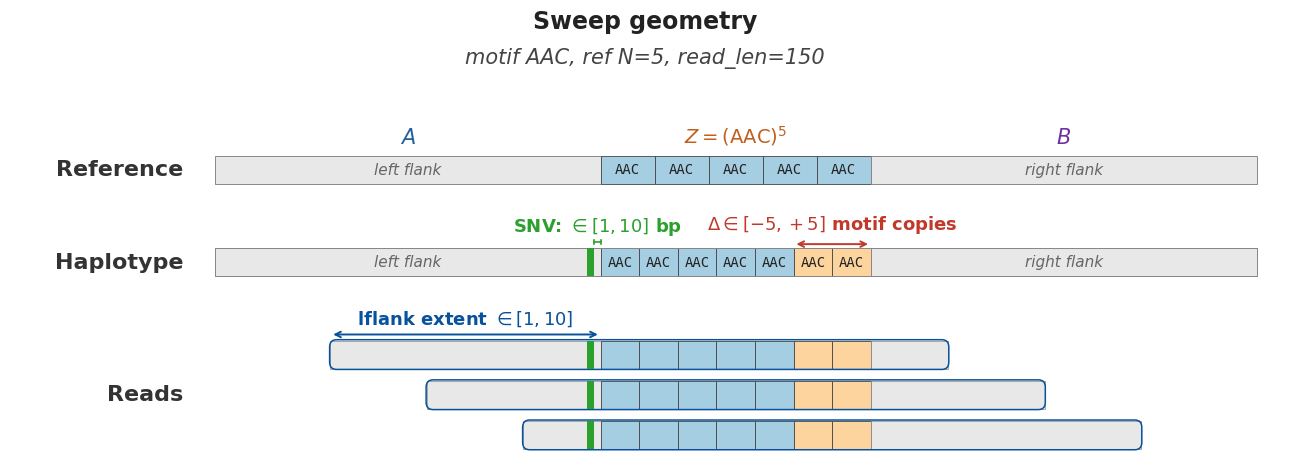

In [13]:
plot_layout_schematic(
    motif=locus.R,
    ref_n=locus.N,
    delta_example=2,
    snv={"offset_from_boundary": 2},
    delta_range=(-5, 5),
    snv_offset_range=(1, 10),
    lflank_range=(1, 10),
    suptitle="Sweep geometry",
    subtitle=f"motif {locus.R}, ref N={locus.N}, read_len={READ_LEN}",
);


Sweep shape — one row per cell of `variant × read × method × orient`:

```python
# Dimensions:
#   variant : haplotype configuration  (delta; for val2, +snv)
#   read    : one per lflank_extent, in order from tile_reads
#   method  : "BWA-std" | "BWA-no-clip" | "NW-flex"
#   orient  : "fwd" | "rc"
#
# The reference is fixed per (method, orient) — it doesn't depend on the
# variant.  So every variant's reads can be aligned together in a single
# batched call per (method, orient).  Variants get split apart afterward
# for per-cell ground truth / classify.
#
# Bounds come from tile_reads' geometry — no filtering, no by-lflank dict.

# 1.  Flatten every variant's reads into one list, remembering the slice.
all_reads = []
slices    = []                                        # (variant, lo, hi)
for variant in variants:
    reads = tile_reads(variant.hap, READ_LEN, K_MIN_FLANK)
    lo    = len(all_reads)
    all_reads.extend(reads)
    slices.append((variant, lo, lo + len(reads)))

# 2.  One batched alignment per (method, orient) over every read at once.
#     m.run handles its own reference / mirror-read transformation.
hits = {
    (m.name, orient): m.run(all_reads, orient)
    for m in methods
    for orient in ("fwd", "rc")
}

# 3.  Per-cell ground truth + classify, walking the slices back out.
rows = []
for variant, lo, hi in slices:
    for i in range(lo, hi):
        r = all_reads[i]
        for m in methods:
            for orient in ("fwd", "rc"):
                truth = m.truth(r, variant.hap, orient)
                state = m.classify(hits[m.name, orient][i], truth, orient)
                rows.append({
                    **variant.label,
                    "lflank": r.lflank_extent,
                    "method": m.name,
                    "orient": orient,
                    "state":  state,
                })

df = pd.DataFrame(rows)
```

In [14]:
# Sweep parameters
DELTAS         = list(range(-5, 6))
LFLANK_EXTENTS = list(range(1, 11))           # boundary-stressed reads
COMBINE        = "best"
TARGET_LFLANKS = set(LFLANK_EXTENTS)

methods = [
    BWAMethod("BWA-std",     locus, rc_locus_X, rc_zone,
              no_clip=False, score_kwargs=sc_kw),
    BWAMethod("BWA-no-clip", locus, rc_locus_X, rc_zone,
              no_clip=True,  score_kwargs=sc_kw),
    NWFlexMethod("NW-flex",  nwflex_locus, rc_nwflex_X, rc_nwflex_zone,
                 ep_fwd, ep_rc, score_kwargs=sc_kw),
]


def _make_variant(label, hap):
    """Notebook-local wrapper that binds this notebook's tiling
    constants (READ_LEN, K_MIN_FLANK, TARGET_LFLANKS) to the package's
    `make_variant`."""
    return make_variant(label, hap,
                        read_len=READ_LEN, k_min_flank=K_MIN_FLANK,
                        target_lflanks=TARGET_LFLANKS)

## First comparison — length variation only

We run the simulation above with the haplotype flanks left untouched and the repeat count varying over $N + \Delta$ for a small range of $\Delta$. We tabulate correctness for each method as a function of flank extent and $\Delta$ and present the result as a heatmap with one panel per method.

**Expected result.** NW-flex is uniformly correct as long as the read has any flank extent. BWA-MEM at standard parameters fails along the boundary even though the haplotype differs from the reference only in the repeat count. The no-clip arm recovers some of these cases but not all.

In [15]:

# ---- val1: length variation only ----------------------------------------
variants = [
    _make_variant({"delta": d}, build_haplotype(locus, delta=d))
    for d in DELTAS
]
val1_long = sweep(variants, methods)
val1_df   = pivot_for_heatmap(val1_long, combine=COMBINE)
print(f"Sweep: {len(LFLANK_EXTENTS)} lflanks × {len(DELTAS)} Δs × "
      f"{len(methods)} arms = {len(val1_df)} verdicts  (combine={COMBINE!r})")
val1_df.groupby("arm")["state"].value_counts().unstack(fill_value=0)


Sweep: 10 lflanks × 11 Δs × 3 arms = 330 verdicts  (combine='best')


state,D,M,P,T
arm,,,,
BWA-no-clip,18,0,92,0
BWA-std,19,61,28,2
NW-flex,0,0,110,0


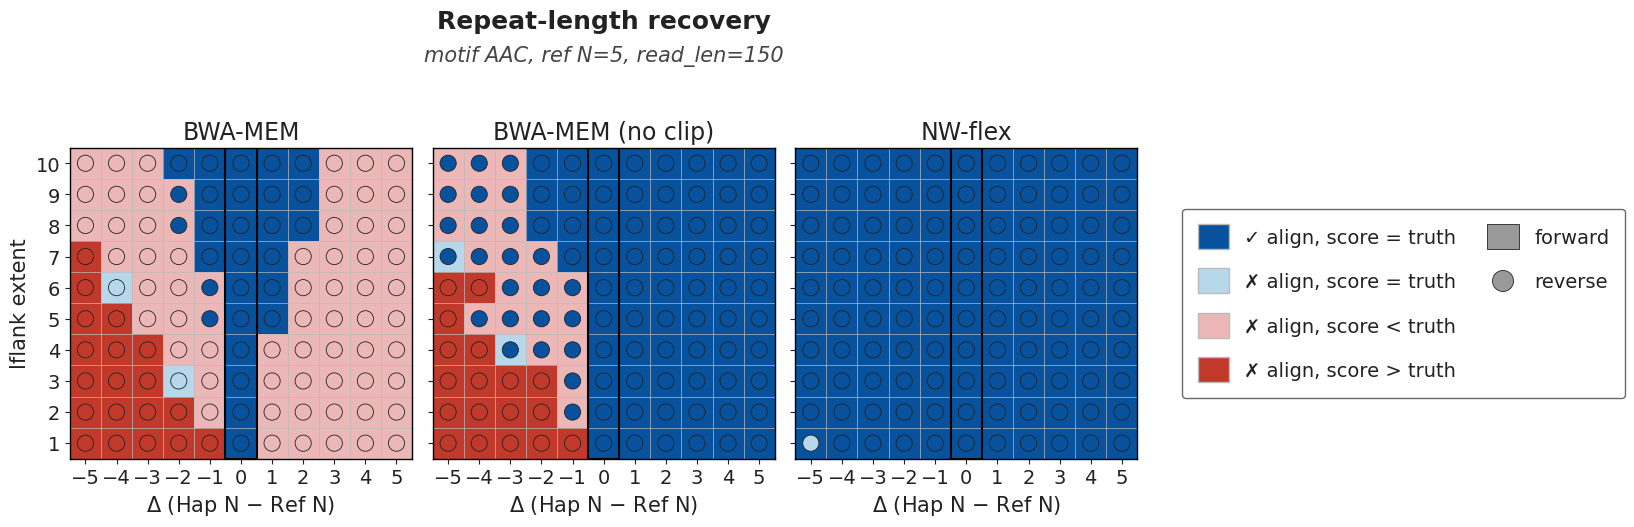

In [16]:
ARM_TITLES = {
    "BWA-std":     "BWA-MEM",
    "BWA-no-clip": "BWA-MEM (no clip)",
    "NW-flex":     "NW-flex",
}

plot_correctness_heatmap(
    val1_df,
    deltas=DELTAS,
    lflanks=LFLANK_EXTENTS,
    arm_titles=ARM_TITLES,
    suptitle="Repeat-length recovery",
    subtitle=f"motif {locus.R}, ref N={locus.N}, read_len={READ_LEN}",
);

## Second comparison — a single SNV in the flank

We repeat the first comparison with one change: the haplotype carries a single SNV at a fixed position. We choose for our example a single base change in the left flank, two bases before the start of the repeat. The locus, the read tiling, and the alignment configurations are unchanged.

**Expected result.** The same heatmap now reads differently. NW-flex remains correct in the regime where it has flank overhang, but not always — sometimes the local sequence and variant have a higher-value alignment. The no-clip arm — the one that recovered the easy cases above — now fails on the reads that cross the SNV.

In [17]:
# SNV: 2 bp into the left flank from the repeat boundary; alt = any non-ref base.
SNV_LFLANK_OFFSET = 2
SNV_POS = locus.s - SNV_LFLANK_OFFSET
SNV_REF = locus.X[SNV_POS]
SNV_ALT = next(b for b in "ACGT" if b != SNV_REF)
print(f"SNV at hap pos {SNV_POS}  ({SNV_LFLANK_OFFSET} bp into lflank from "
      f"boundary at {locus.s}):  {SNV_REF} → {SNV_ALT}")

variants = [
    _make_variant({"delta": d},
                  build_haplotype(locus, delta=d, snv=(SNV_POS, SNV_ALT)))
    for d in DELTAS
]
val2_long = sweep(variants, methods)
val2_df   = pivot_for_heatmap(val2_long, combine=COMBINE)
print(f"Sweep: {len(LFLANK_EXTENTS)} lflanks × {len(DELTAS)} Δs × "
      f"{len(methods)} arms = {len(val2_df)} verdicts  (combine={COMBINE!r})")
val2_df.groupby("arm")["state"].value_counts().unstack(fill_value=0)


SNV at hap pos 198  (2 bp into lflank from boundary at 200):  T → A
Sweep: 10 lflanks × 11 Δs × 3 arms = 330 verdicts  (combine='best')


state,D,M,P,T
arm,,,,
BWA-no-clip,52,0,58,0
BWA-std,37,59,12,2
NW-flex,3,0,77,30


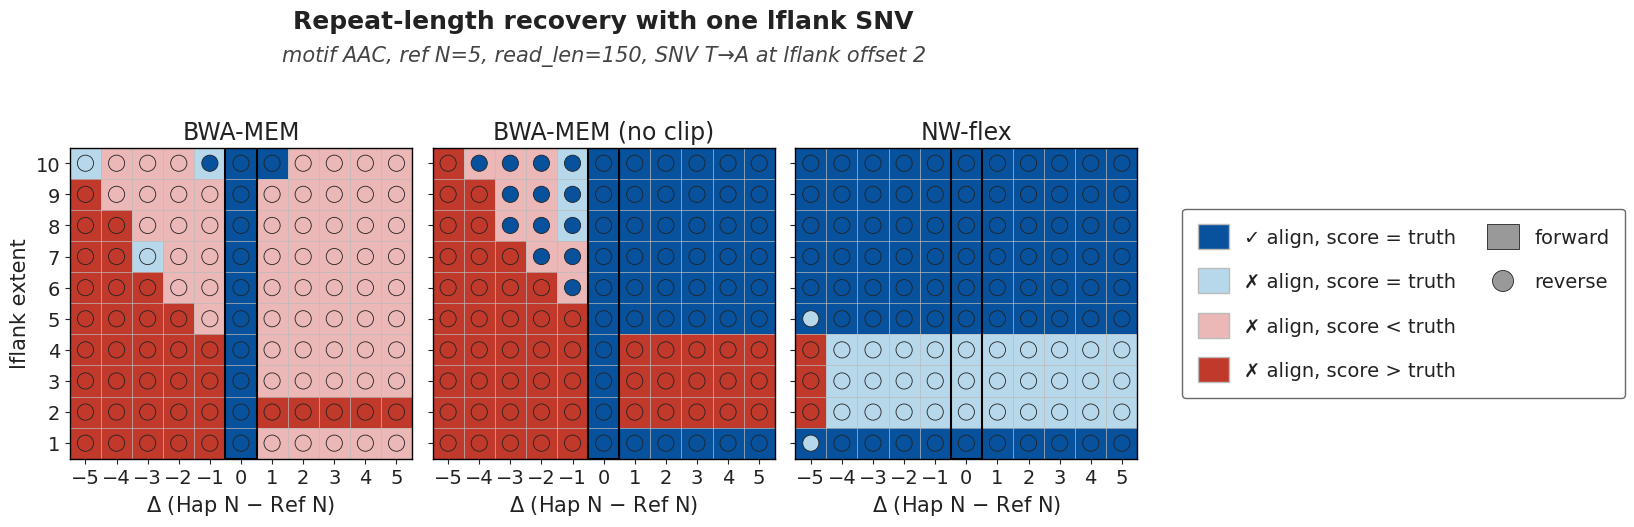

In [18]:
plot_correctness_heatmap(
    val2_df,
    deltas=DELTAS,
    lflanks=LFLANK_EXTENTS,
    arm_titles=ARM_TITLES,
    suptitle="Repeat-length recovery with one lflank SNV",
    subtitle=(
        f"motif {locus.R}, ref N={locus.N}, read_len={READ_LEN}, "
        f"SNV {SNV_REF}→{SNV_ALT} at lflank offset {SNV_LFLANK_OFFSET}"
    ),
);

### Varying the SNV position

The comparison above placed the SNV 2 bp inside the left flank from the repeat boundary. Here we sweep the offset from 1 to 5 bp and stack one heatmap row per offset. Each row uses the same `(delta × lflank × method × orient)` sweep machinery; only the SNV position changes per variant.


In [21]:
SNV_OFFSETS = list(range(1, 11))   # offsets 1..10 bp inside the left flank

variants = []
for k in SNV_OFFSETS:
    snv_pos = locus.s - k
    snv_alt = next(b for b in "ACGT" if b != locus.X[snv_pos])
    for d in DELTAS:
        h = build_haplotype(locus, delta=d, snv=(snv_pos, snv_alt))
        variants.append(_make_variant({"delta": d, "snv_offset": k}, h))

snv_sweep_long = sweep(variants, methods)
snv_sweep_df   = pivot_for_heatmap(snv_sweep_long, combine=COMBINE)
print(f"Sweep: {len(SNV_OFFSETS)} offsets × {len(DELTAS)} Δs × "
      f"{len(LFLANK_EXTENTS)} lflanks × {len(methods)} arms = "
      f"{len(snv_sweep_df)} verdicts  (combine={COMBINE!r})")
(snv_sweep_df.groupby(["snv_offset", "arm"])["state"]
             .value_counts().unstack(fill_value=0))


Sweep: 10 offsets × 11 Δs × 10 lflanks × 3 arms = 3300 verdicts  (combine='best')


state                    D   M    P   T
snv_offset arm                         
1          BWA-no-clip  55  11   44   0
           BWA-std      48  49   11   2
           NW-flex      11   0   66  33
2          BWA-no-clip  52   0   58   0
           BWA-std      37  59   12   2
           NW-flex       3   0   77  30
3          BWA-no-clip  31   0   79   0
           BWA-std      30  65   12   3
           NW-flex       0   0  110   0
4          BWA-no-clip  31   0   79   0
           BWA-std      28  66   12   4
           NW-flex       0   0  110   0
5          BWA-no-clip  34   0   76   0
           BWA-std      27  68   12   3
           NW-flex       0   0  110   0
6          BWA-no-clip  23   0   87   0
           BWA-std      25  68   14   3
           NW-flex       0   0  110   0
7          BWA-no-clip  26   0   84   0
           BWA-std      23  67   16   4
           NW-flex       0   0  110   0
8          BWA-no-clip  22   0   88   0
           BWA-std      22  67   18   3
           NW-flex       0   0  110   0
9          BWA-no-clip  19   0   91   0
           BWA-std      20  65   22   3
           NW-flex       0   0  110   0
10         BWA-no-clip  20   0   90   0
           BWA-std      19  62   26   3
           NW-flex       0   0  110   0

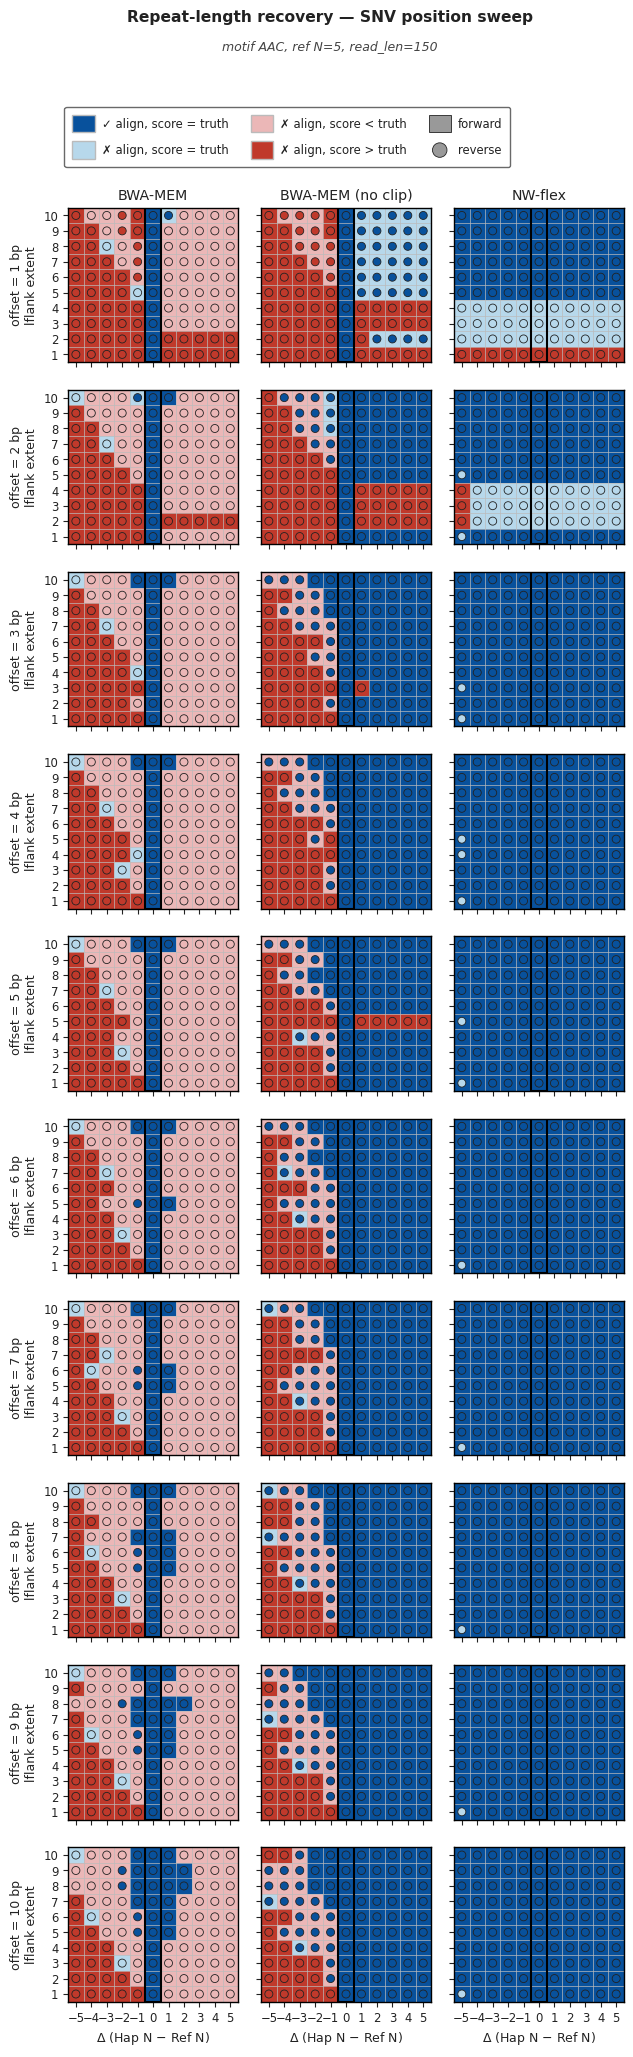

In [22]:
rows = [(k, snv_sweep_df[snv_sweep_df["snv_offset"] == k]) for k in SNV_OFFSETS]

plot_correctness_heatmap_rows(
    rows,
    deltas=DELTAS, lflanks=LFLANK_EXTENTS, arm_titles=ARM_TITLES,
    row_label_fn=lambda k: f"offset = {k} bp",
    suptitle="Repeat-length recovery — SNV position sweep",
    subtitle=f"motif {locus.R}, ref N={locus.N}, read_len={READ_LEN}",
    scale=0.4,
    font_scale=0.6,
);


## Third comparison — compound repeat

A third comparison would change the locus structure: the reference is built from two adjacent repeat motifs joined by a short interrupting sequence,
$$X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B,$$
and the haplotype varies both counts independently. The reads, the alignment methods, and the correctness rule carry over.

**Deferred to Notebook 8**, which sets up the compound locus and runs the $(\Delta_1, \Delta_2)$ sweep using this notebook's correctness rule and scoring conventions.


## Summary

Across both comparisons, NW-flex matches the haplotype's repeat-region length whenever the read has flank overhang on both sides. BWA-MEM at standard parameters loses the flank-adjacent reads to soft-clipping; raising the clip penalty recovers the no-variant cases but not the cases with a boundary-adjacent SNV.

The methods differ structurally. When the only difference between haplotype and reference is the repeat count, NW-flex's EP pattern is guaranteed to find the optimum over the allowed counts; a clip-based aligner has no such guarantee, and its result depends on the scoring tradeoffs it makes at the boundary.
